# TASK #1: UNDERSTAND THE PROBLEM STATEMENT AND BUSINESS CASE

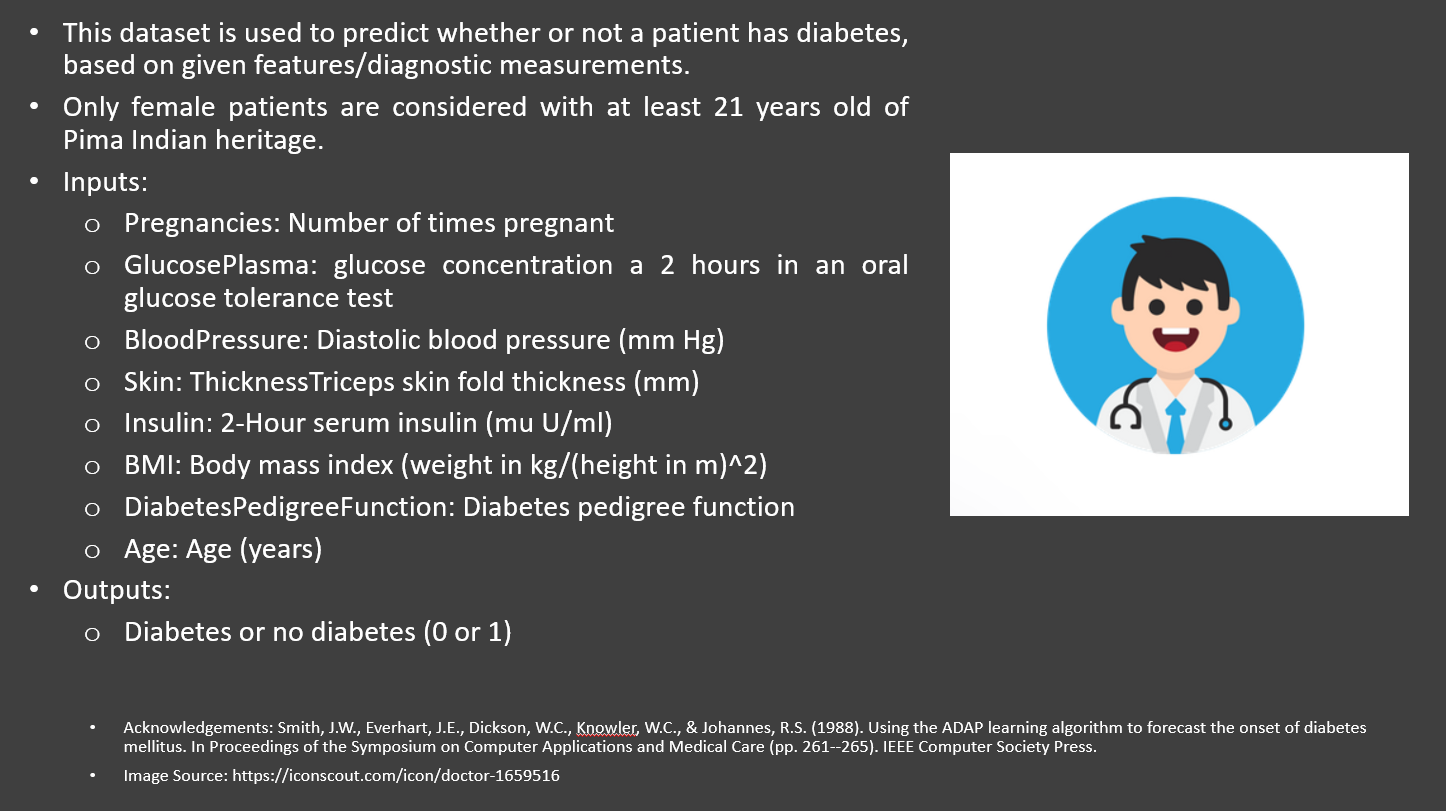

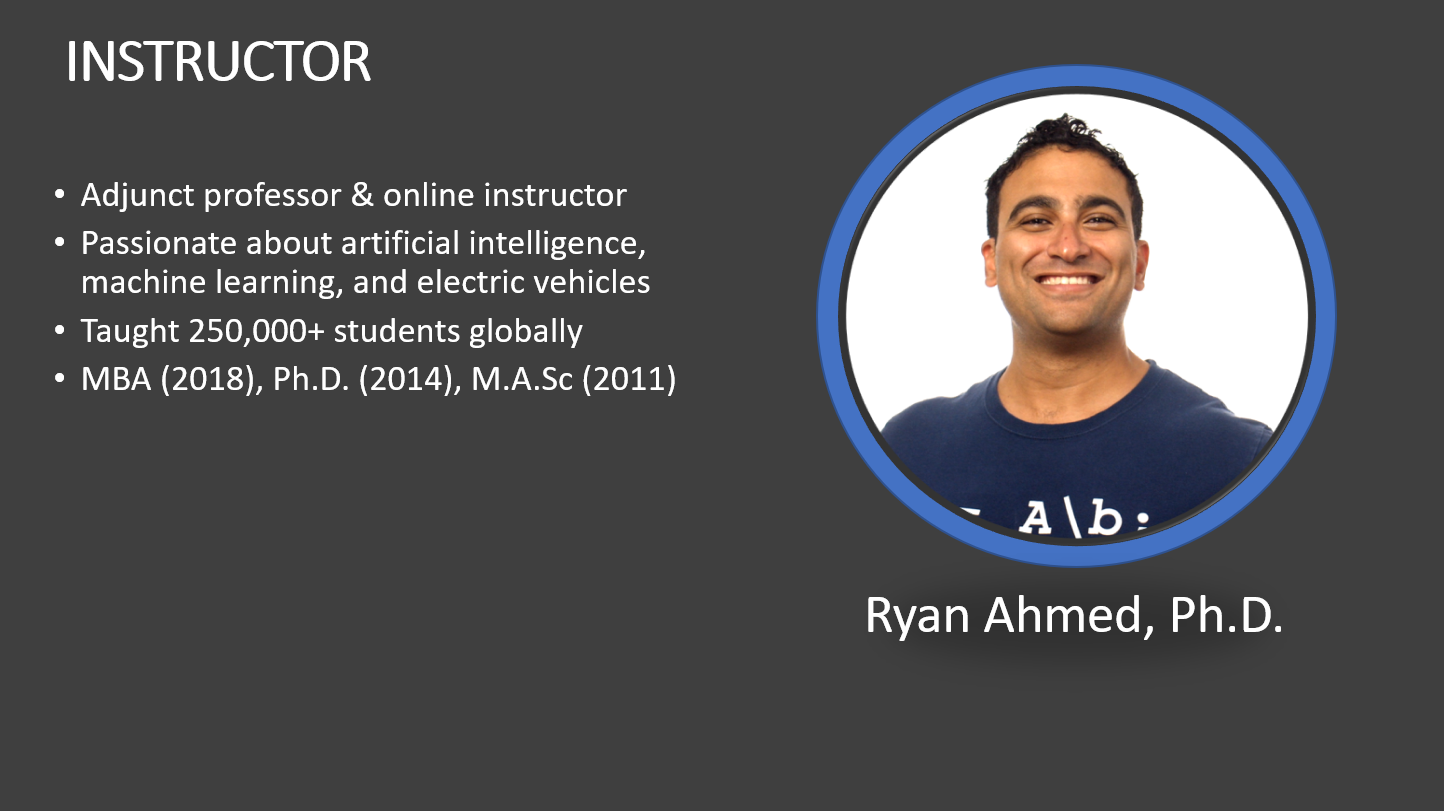

# TASK #2: IMPORT LIBRARIES AND DATASETS

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from jupyterthemes import jtplot
jtplot.style(theme = 'monokai', context = 'notebook', ticks = True, grid = False) 
# setting the style of the notebook to be monokai theme  
# this line of code is important to ensure that we are able to see the x and y axes clearly
# If you don't run this code line, you will notice that the xlabel and ylabel on any plot is black on black and it will be hard to see them. 


2026-03-23 12:17:43.537191: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# You have to include the full link to the csv file containing your dataset
diabetes=pd.read_csv('diabetes.csv')

In [3]:
diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
diabetes.head(7)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1


In [5]:
diabetes.tail(9)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
759,6,190,92,0,0,35.5,0.278,66,1
760,2,88,58,26,16,28.4,0.766,22,0
761,9,170,74,31,0,44.0,0.403,43,1
762,9,89,62,0,0,22.5,0.142,33,0
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [6]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**PRACTICE OPPORTUNITY #1 [OPTIONAL]:**
- **What is the average BMI?**
- **What is the average, minimum and maximum age in this study?**

In [7]:
diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<AxesSubplot: xlabel='Outcome', ylabel='count'>

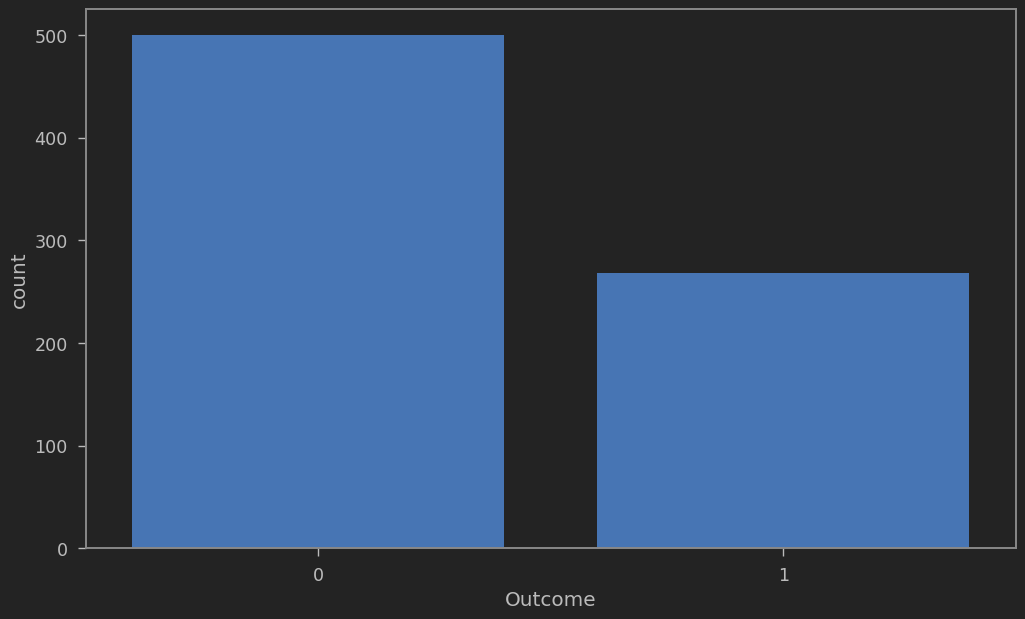

In [8]:
plt.figure(figsize = (12, 7))
sns.countplot(x='Outcome',data=diabetes)


# TASK #3: PERFORM DATA VISUALIZATION

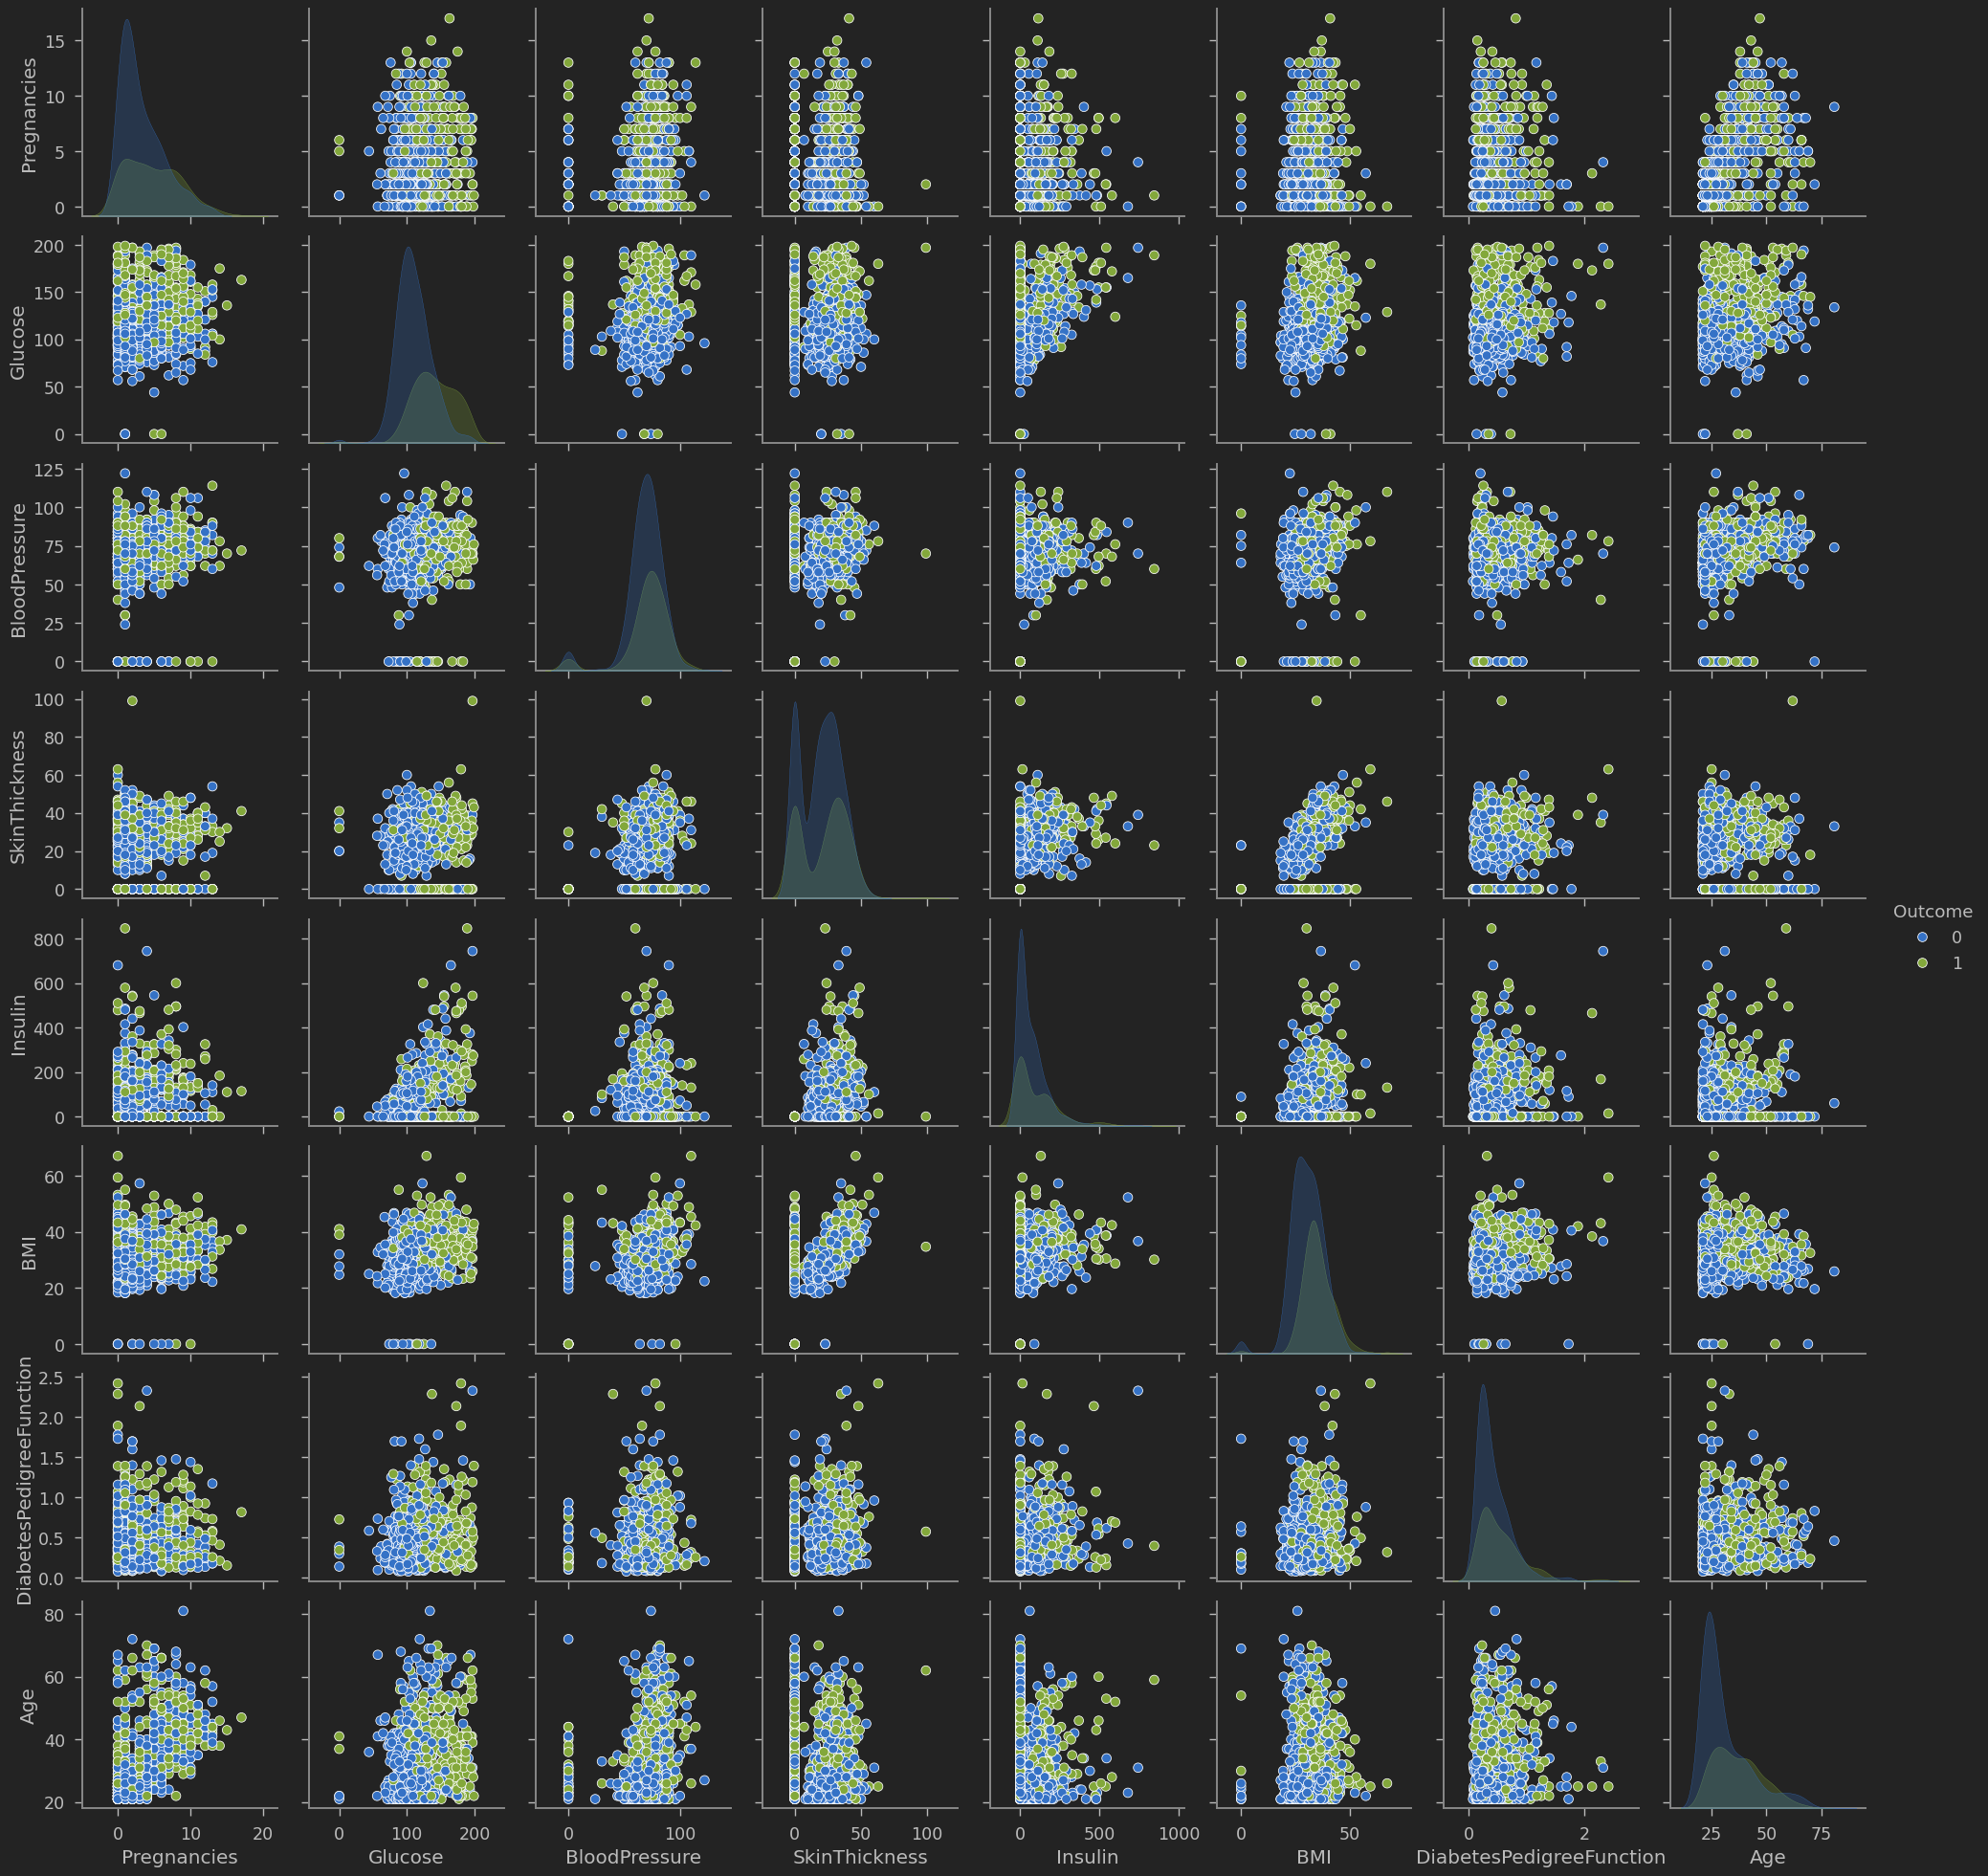

In [9]:
sns.pairplot(diabetes, hue = 'Outcome', vars = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'])

# TASK #4: SPLIT THE DATA AND PREPARE IT FOR TRAINING

In [10]:
X = diabetes.iloc[:, 0:8].values

In [11]:
X

array([[  6.   , 148.   ,  72.   , ...,  33.6  ,   0.627,  50.   ],
       [  1.   ,  85.   ,  66.   , ...,  26.6  ,   0.351,  31.   ],
       [  8.   , 183.   ,  64.   , ...,  23.3  ,   0.672,  32.   ],
       ...,
       [  5.   , 121.   ,  72.   , ...,  26.2  ,   0.245,  30.   ],
       [  1.   , 126.   ,  60.   , ...,  30.1  ,   0.349,  47.   ],
       [  1.   ,  93.   ,  70.   , ...,  30.4  ,   0.315,  23.   ]])

In [12]:
y = diabetes.iloc[:, 8].values

In [13]:
y

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,

In [14]:
# Feature Scaling is a must in ANN
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X=sc.fit_transform(X)

In [15]:
X

array([[ 0.63994726,  0.84832379,  0.14964075, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 ,  0.00330087,  0.14964075, ..., -0.73518964,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.1597866 , -0.47073225, ..., -0.24020459,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.8730192 ,  0.04624525, ..., -0.20212881,
        -0.47378505, -0.87137393]])

In [16]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [17]:
X_train.shape

(614, 8)

In [18]:
X_test.shape

(154, 8)

**PRACTICE OPPORTUNITY #2 [OPTIONAL]:**
- **Change the split ratio to 25% for testing and 75% for training**
- **Ensure that the split was successful**

In [19]:
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.25)

In [20]:
X_train.shape

(576, 8)

In [21]:
X_test.shape

(192, 8)

# TASK #5: BUILD A NEURAL NETWORK MODEL USING KERAS

In [22]:
# !pip install tensorflow
import tensorflow as tf

ANN_model = tf.keras.models.Sequential()
ANN_model.add(tf.keras.layers.Dense(units=400, activation='relu', input_shape=(8, )))
ANN_model.add(tf.keras.layers.Dropout(0.2))

ANN_model.add(tf.keras.layers.Dense(units=400, activation='relu'))
ANN_model.add(tf.keras.layers.Dropout(0.2))

ANN_model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))


2026-03-23 12:18:03.956020: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [23]:
ANN_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 400)               3600      
                                                                 
 dropout (Dropout)           (None, 400)               0         
                                                                 
 dense_1 (Dense)             (None, 400)               160400    
                                                                 
 dropout_1 (Dropout)         (None, 400)               0         
                                                                 
 dense_2 (Dense)             (None, 1)                 401       
                                                                 
Total params: 164,401
Trainable params: 164,401
Non-trainable params: 0
_________________________________________________________________


# TASK #6: COMPILE AND TRAIN THE ANN MODEL

In [24]:
ANN_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics = ['accuracy'])

In [25]:
epochs_hist=ANN_model.fit(X_train,y_train,epochs=200)

Epoch 1/200
18/18 [==============================] - 1s 6ms/step - loss: 0.5774 - accuracy: 0.6892
Epoch 2/200
18/18 [==============================] - 0s 6ms/step - loss: 0.4711 - accuracy: 0.7708
Epoch 3/200
18/18 [==============================] - 0s 5ms/step - loss: 0.4518 - accuracy: 0.7726
Epoch 4/200
18/18 [==============================] - 0s 5ms/step - loss: 0.4452 - accuracy: 0.7830
Epoch 5/200
18/18 [==============================] - 0s 5ms/step - loss: 0.4295 - accuracy: 0.7847
Epoch 6/200
18/18 [==============================] - 0s 2ms/step - loss: 0.4258 - accuracy: 0.7812
Epoch 7/200
18/18 [==============================] - 0s 2ms/step - loss: 0.4177 - accuracy: 0.7986
Epoch 8/200
18/18 [==============================] - 0s 5ms/step - loss: 0.4199 - accuracy: 0.7812
Epoch 9/200
18/18 [==============================] - 0s 5ms/step - loss: 0.4113 - accuracy: 0.7951
Epoch 10/200
18/18 [==============================] - 0s 5ms/step - loss: 0.4001 - accuracy: 0.8038
Epoch 11/

In [26]:
y_pred=ANN_model.predict(X)

24/24 [==============================] - 0s 858us/step


In [27]:
y_pred

array([[9.99962449e-01],
       [2.67837724e-10],
       [9.99845505e-01],
       [3.84915673e-16],
       [9.99999046e-01],
       [1.08468602e-03],
       [9.03114138e-17],
       [1.00000000e+00],
       [1.00000000e+00],
       [9.99999046e-01],
       [2.30240068e-04],
       [9.97935772e-01],
       [1.70062674e-04],
       [1.00000000e+00],
       [9.99707401e-01],
       [9.99746263e-01],
       [9.99441803e-01],
       [9.78198588e-01],
       [3.08069611e-05],
       [9.97153759e-01],
       [3.36029828e-02],
       [8.69541313e-04],
       [1.00000000e+00],
       [9.84919190e-01],
       [6.88706219e-01],
       [9.83344853e-01],
       [6.55844927e-01],
       [8.19890420e-14],
       [4.70377684e-01],
       [5.64369664e-04],
       [3.64838634e-04],
       [9.84417617e-01],
       [5.06754317e-15],
       [1.80674233e-05],
       [7.43158638e-01],
       [1.58535590e-06],
       [1.56446993e-02],
       [9.99663651e-01],
       [1.70689036e-05],
       [3.60596925e-04],


In [28]:
y_pred = (y_pred > 0.5)

In [29]:
y_pred

array([[ True],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

# TASK #7: EVALUATE TRAINED MODEL PERFORMANCE 

In [30]:
epochs_hist.history.keys()

dict_keys(['loss', 'accuracy'])

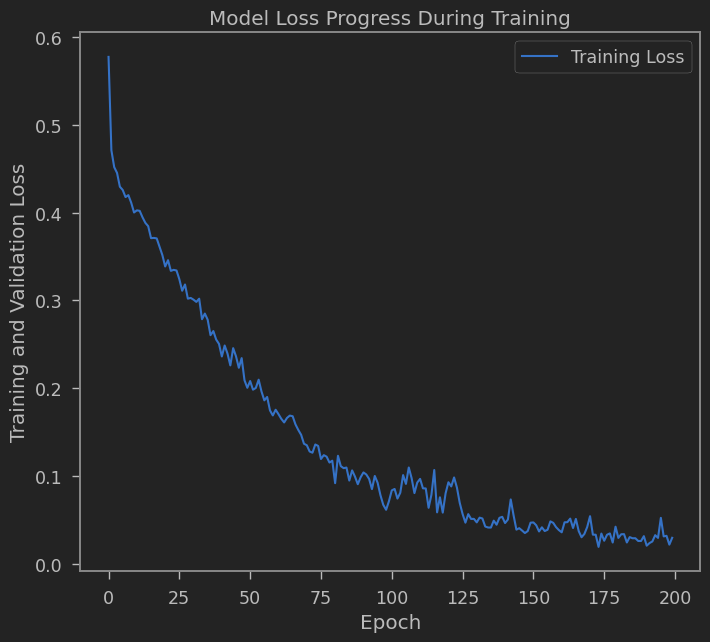

In [31]:
plt.plot(epochs_hist.history['loss'])
plt.title('Model Loss Progress During Training')
plt.xlabel('Epoch')
plt.ylabel('Training and Validation Loss')
plt.legend(['Training Loss'])

6/6 [==============================] - 0s 1ms/step
(192,) (192,)


<AxesSubplot: >

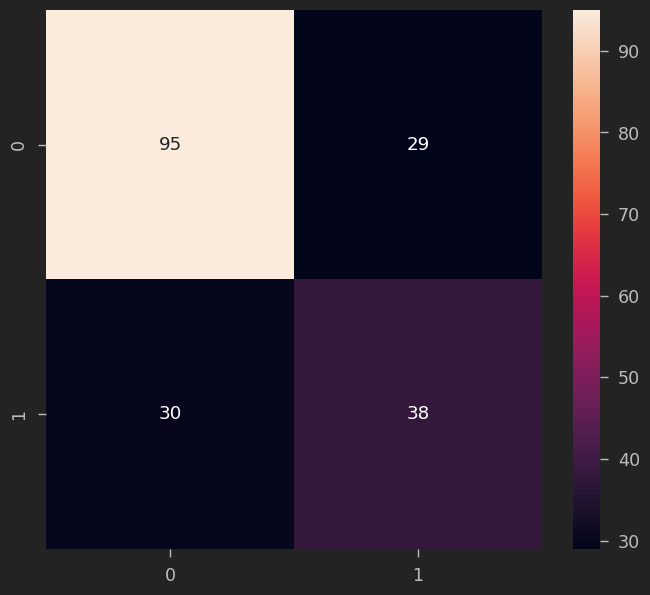

In [32]:
# Prediction
y_pred = ANN_model.predict(X_test)

# Convert probabilities to 0/1
y_pred = (y_pred > 0.5).astype(int)

# Flatten
y_pred = y_pred.reshape(-1)

# Check shapes
print(y_test.shape, y_pred.shape)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
sns.heatmap(cm, annot=True)

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.77      0.76       124
           1       0.57      0.56      0.56        68

    accuracy                           0.69       192
   macro avg       0.66      0.66      0.66       192
weighted avg       0.69      0.69      0.69       192



**PRACTICE OPPORTUNITY #3:**
- **Change the network architecture and retrain the model**

In [34]:
# !pip install tensorflow
import tensorflow as tf

ANN_model = tf.keras.models.Sequential()
ANN_model.add(tf.keras.layers.Dense(units=700, activation='relu', input_shape=(8, )))
ANN_model.add(tf.keras.layers.Dropout(0.2))

ANN_model.add(tf.keras.layers.Dense(units=700, activation='relu'))
ANN_model.add(tf.keras.layers.Dropout(0.2))

ANN_model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))


# TASK #8: TRAIN AND EVALUATE AN XG-BOOST ALGORITHM

In [35]:
!pip install xgboost


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [36]:
# Train an XGBoost classifier model 

import xgboost as xgb
XGB_model = xgb.XGBClassifier(learning_rate = 0.1, max_depth = 5, n_estimators = 10)
XGB_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=10, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [37]:
result_train = XGB_model.score(X_train, y_train)
print("Accuracy : {}".format(result_train))

Accuracy : 0.8402777777777778


In [38]:
# predict the score of the trained model using the testing dataset

result_test = XGB_model.score(X_test, y_test)
print("Accuracy : {}".format(result_test))

Accuracy : 0.75


In [39]:
# make predictions on the test data
y_predict = XGB_model.predict(X_test)


In [40]:
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.76      0.90      0.82       124
           1       0.73      0.47      0.57        68

    accuracy                           0.75       192
   macro avg       0.74      0.69      0.70       192
weighted avg       0.75      0.75      0.73       192



Text(0.5, 35.38888888888887, 'Actual class')

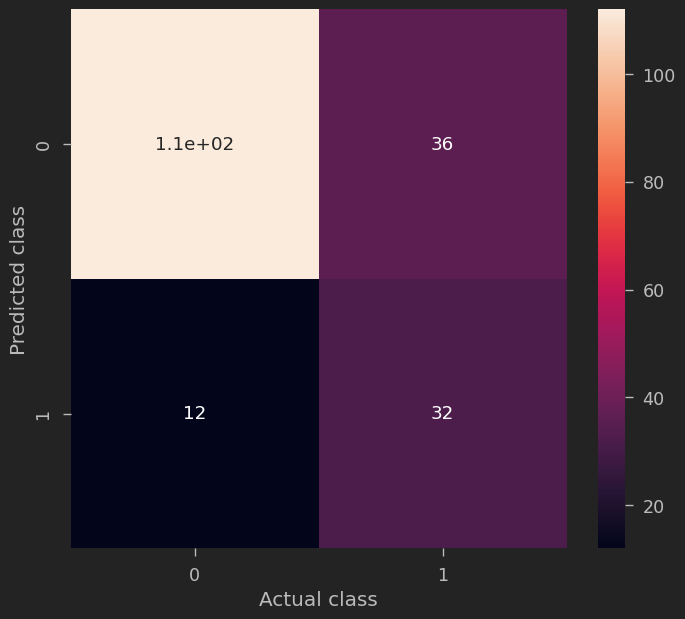

In [41]:
cm = confusion_matrix(y_predict, y_test) 
sns.heatmap(cm, annot = True)
plt.ylabel('Predicted class')
plt.xlabel('Actual class')

**PRACTICE OPPORTUNITY #4 [OPTIONAL]:**
- **Train a logistic regression classifier model and assess its performance**

# GREAT JOB!

# PRACTICE OPPORTUNITIES SOLUTION

**PRACTICE OPPORTUNITY #1 SOLUTION:**
- **What is the average BMI?**
- **What is the average, minimum and maximum age in this study?**

In [42]:
diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**PRACTICE OPPORTUNITY #2 SOLUTION:**
- **Change the split ratio to 25% for testing and 75% for training**
- **Ensure that the split was successful**

In [43]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)


In [44]:
print(X_train.shape)
print(X_test.shape)

(576, 8)
(192, 8)


**PRACTICE OPPORTUNITY #3 SOLUTION:**
- **Change the network architecture and retrain the model**

In [45]:
ANN_model = tf.keras.models.Sequential()
ANN_model.add(tf.keras.layers.Dense(units=700, activation='relu', input_shape=(8, )))
ANN_model.add(tf.keras.layers.Dropout(0.4))

ANN_model.add(tf.keras.layers.Dense(units=700, activation='relu'))
ANN_model.add(tf.keras.layers.Dropout(0.4))

ANN_model.add(tf.keras.layers.Dense(units=700, activation='relu'))
ANN_model.add(tf.keras.layers.Dropout(0.4))

ANN_model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))


In [46]:
ANN_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 700)               6300      
                                                                 
 dropout_4 (Dropout)         (None, 700)               0         
                                                                 
 dense_7 (Dense)             (None, 700)               490700    
                                                                 
 dropout_5 (Dropout)         (None, 700)               0         
                                                                 
 dense_8 (Dense)             (None, 700)               490700    
                                                                 
 dropout_6 (Dropout)         (None, 700)               0         
                                                                 
 dense_9 (Dense)             (None, 1)                

**PRACTICE OPPORTUNITY #4 SOLUTION:**
- **Train a logistic regression classifier model and assess its performance**

Accuracy : 0.734375
              precision    recall  f1-score   support

           0       0.75      0.88      0.81       123
           1       0.69      0.48      0.56        69

    accuracy                           0.73       192
   macro avg       0.72      0.68      0.69       192
weighted avg       0.73      0.73      0.72       192



Text(0.5, 35.38888888888887, 'Actual class')

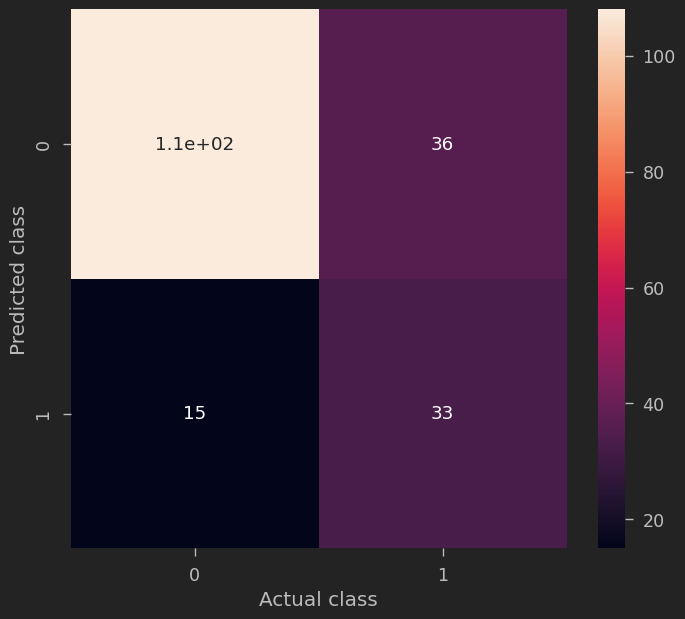

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model_LR = LogisticRegression()
        
model_LR.fit(X_train, y_train)

# predict the score of the trained model using the testing dataset

result_test = model_LR.score(X_test, y_test)
print("Accuracy : {}".format(result_test))

# make predictions on the test data
y_predict = model_LR.predict(X_test)

from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, y_predict))

cm = confusion_matrix(y_predict, y_test) 
sns.heatmap(cm, annot = True)
plt.ylabel('Predicted class')
plt.xlabel('Actual class')
